In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/processed/conformal_predictions_phase3.csv")
print(df.shape)
df[['id','day','sales','prediction','lower_bound','upper_bound']].head()

(2940, 34)


,id,day,sales,prediction,lower_bound,upper_bound
0,FOODS_1_022_CA_4_validation,1886,0,0.087015,0.0,1.810284
1,FOODS_1_022_CA_4_validation,1887,0,0.083071,0.0,1.806339
2,FOODS_1_022_CA_4_validation,1888,0,0.083071,0.0,1.806339
3,FOODS_1_022_CA_4_validation,1889,0,0.083071,0.0,1.806339
4,FOODS_1_022_CA_4_validation,1890,0,0.103592,0.0,1.826860


In [5]:
holding_cost = 1          # cost per extra unit
stockout_cost = 5         # penalty for unmet demand
lead_time = 7            # days to replenish

In [6]:
df['safety_stock'] = df['upper_bound'] - df['prediction']
df['lead_time_demand'] = df['prediction'] * lead_time
df['reorder_point'] = df['lead_time_demand'] + df['safety_stock']

df[['sales','prediction','lower_bound','upper_bound','safety_stock','lead_time_demand','reorder_point']].head()

,sales,prediction,lower_bound,upper_bound,safety_stock,lead_time_demand,reorder_point
0,0,0.087015,0.0,1.810284,1.723269,0.609105,2.332373
1,0,0.083071,0.0,1.806339,1.723269,0.581494,2.304763
2,0,0.083071,0.0,1.806339,1.723269,0.581494,2.304763
3,0,0.083071,0.0,1.806339,1.723269,0.581494,2.304763
4,0,0.103592,0.0,1.826860,1.723269,0.725142,2.448410


In [7]:
df['point_policy_order'] = np.round(df['prediction'])
df['conformal_policy_order'] = np.ceil(df['reorder_point'])

df[['sales','prediction','upper_bound','point_policy_order','conformal_policy_order']].head()

,sales,prediction,upper_bound,point_policy_order,conformal_policy_order
0,0,0.087015,1.810284,0.0,3.0
1,0,0.083071,1.806339,0.0,3.0
2,0,0.083071,1.806339,0.0,3.0
3,0,0.083071,1.806339,0.0,3.0
4,0,0.103592,1.826860,0.0,3.0


In [8]:
# Costs for point forecast policy
df['point_holding'] = np.maximum(df['point_policy_order'] - df['sales'], 0) * holding_cost
df['point_stockout'] = np.maximum(df['sales'] - df['point_policy_order'], 0) * stockout_cost
df['point_total'] = df['point_holding'] + df['point_stockout']

# Costs for conformal policy
df['conf_holding'] = np.maximum(df['conformal_policy_order'] - df['sales'], 0) * holding_cost
df['conf_stockout'] = np.maximum(df['sales'] - df['conformal_policy_order'], 0) * stockout_cost
df['conf_total'] = df['conf_holding'] + df['conf_stockout']

In [9]:
point_cost = df['point_total'].sum()
conf_cost = df['conf_total'].sum()

point_stockouts = (df['point_stockout'] > 0).sum()
conf_stockouts = (df['conf_stockout'] > 0).sum()

improvement = ((point_cost - conf_cost) / point_cost * 100) if point_cost != 0 else 0

print("Point policy cost:", point_cost)
print("Conformal policy cost:", conf_cost)
print("Cost improvement (%):", improvement)
print("Point policy stockout events:", point_stockouts)
print("Conformal policy stockout events:", conf_stockouts)

Point policy cost: 7329.0
Conformal policy cost: 22555.0
Cost improvement (%): -207.75003411106562
Point policy stockout events: 646
Conformal policy stockout events: 10


In [10]:
safety_factors = [0.2, 0.4, 0.6, 0.8, 1.0]

In [11]:
results_list = []

for sf in safety_factors:

    temp_df = df.copy()

    temp_df['adjusted_safety_stock'] = sf * temp_df['safety_stock']

    temp_df['adjusted_reorder_point'] = (
        temp_df['lead_time_demand']
        + temp_df['adjusted_safety_stock']
    )

    temp_df['adjusted_order'] = np.ceil(
        temp_df['adjusted_reorder_point']
    )

    holding = np.maximum(
        temp_df['adjusted_order'] - temp_df['sales'],
        0
    ).sum()

    stockout = np.maximum(
        temp_df['sales'] - temp_df['adjusted_order'],
        0
    ).sum()

    total_cost = (
        holding * holding_cost
        + stockout * stockout_cost
    )

    results_list.append(
        [sf, total_cost, stockout]
    )

sensitivity_df = pd.DataFrame(
    results_list,
    columns=[
        'safety_factor',
        'total_cost',
        'stockout_units'
    ]
)

sensitivity_df

,safety_factor,total_cost,stockout_units
0,0.2,18661.0,87.0
1,0.4,19572.0,86.0
2,0.6,20647.0,76.0
3,0.8,21628.0,74.0
4,1.0,22555.0,74.0


In [12]:
sensitivity_df

,safety_factor,total_cost,stockout_units
0,0.2,18661.0,87.0
1,0.4,19572.0,86.0
2,0.6,20647.0,76.0
3,0.8,21628.0,74.0
4,1.0,22555.0,74.0


A sensitivity analysis was performed on the conformal safety stock factor. Results showed that increasing the factor beyond 0.6 led to substantially higher inventory costs while producing only marginal reductions in stockout events. Therefore, a safety factor of 0.6 was selected as the final inventory policy, representing a practical balance between service level and inventory holding cost.

In [13]:
import numpy as np
import pandas as pd

selected_factor = 0.6

df['tuned_safety_stock'] = selected_factor * df['safety_stock']

df['tuned_reorder_point'] = (
    df['lead_time_demand'] + df['tuned_safety_stock']
)

df['tuned_policy_order'] = np.ceil(df['tuned_reorder_point'])

In [14]:
holding_cost = 1
stockout_cost = 5

df['tuned_holding_units'] = np.maximum(
    df['tuned_policy_order'] - df['sales'],
    0
)

df['tuned_stockout_units'] = np.maximum(
    df['sales'] - df['tuned_policy_order'],
    0
)

df['tuned_holding_cost'] = df['tuned_holding_units'] * holding_cost
df['tuned_stockout_cost'] = df['tuned_stockout_units'] * stockout_cost

df['tuned_total_cost'] = (
    df['tuned_holding_cost'] + df['tuned_stockout_cost']
)

tuned_cost = df['tuned_total_cost'].sum()
tuned_stockout_units = df['tuned_stockout_units'].sum()

print("Tuned Conformal Policy")
print("Total Cost:", tuned_cost)
print("Stockout Units:", tuned_stockout_units)

Tuned Conformal Policy
Total Cost: 20647.0
Stockout Units: 76.0


In [15]:
# Point forecast policy: no uncertainty buffer
df['point_policy_order'] = np.ceil(df['lead_time_demand'])

# Conservative conformal policy: full conformal safety stock
df['conservative_policy_order'] = np.ceil(
    df['lead_time_demand'] + df['safety_stock']
)

# Tuned conformal policy: selected safety factor
df['tuned_policy_order'] = np.ceil(
    df['lead_time_demand'] + selected_factor * df['safety_stock']
)


def evaluate_policy(data, order_col, policy_name):
    holding_units = np.maximum(data[order_col] - data['sales'], 0)
    stockout_units = np.maximum(data['sales'] - data[order_col], 0)

    holding_cost_total = holding_units.sum() * holding_cost
    stockout_cost_total = stockout_units.sum() * stockout_cost
    total_cost = holding_cost_total + stockout_cost_total

    return {
        "Policy": policy_name,
        "Total Cost": total_cost,
        "Holding Units": holding_units.sum(),
        "Stockout Units": stockout_units.sum(),
        "Holding Cost": holding_cost_total,
        "Stockout Cost": stockout_cost_total
    }


policy_comparison_df = pd.DataFrame([
    evaluate_policy(df, 'point_policy_order', 'Point Forecast Policy'),
    evaluate_policy(df, 'conservative_policy_order', 'Conservative Conformal Policy'),
    evaluate_policy(df, 'tuned_policy_order', 'Tuned Conformal Policy')
])

policy_comparison_df

,Policy,Total Cost,Holding Units,Stockout Units,Holding Cost,Stockout Cost
0,Point Forecast Policy,17741.0,17266.0,95.0,17266.0,475.0
1,Conservative Conformal Policy,22555.0,22185.0,74.0,22185.0,370.0
2,Tuned Conformal Policy,20647.0,20267.0,76.0,20267.0,380.0


In [16]:
sensitivity_df['cost_increase'] = sensitivity_df['total_cost'].diff()

sensitivity_df['stockout_reduction'] = -sensitivity_df['stockout_units'].diff()

sensitivity_df['cost_per_stockout_reduced'] = (
    sensitivity_df['cost_increase'] / sensitivity_df['stockout_reduction']
)

sensitivity_df

,safety_factor,total_cost,stockout_units,cost_increase,stockout_reduction,cost_per_stockout_reduced
0,0.2,18661.0,87.0,NaN,NaN,NaN
1,0.4,19572.0,86.0,911.0,1.0,911.0
2,0.6,20647.0,76.0,1075.0,10.0,107.5
3,0.8,21628.0,74.0,981.0,2.0,490.5
4,1.0,22555.0,74.0,927.0,-0.0,-inf


In [19]:
import numpy as np

sensitivity_df['cost_per_stockout_reduced'] = np.where(
    sensitivity_df['stockout_reduction'] > 0,
    sensitivity_df['cost_increase'] / sensitivity_df['stockout_reduction'],
    np.nan
)

sensitivity_df

,safety_factor,total_cost,stockout_units,cost_increase,stockout_reduction,cost_per_stockout_reduced
0,0.2,18661.0,87.0,NaN,NaN,NaN
1,0.4,19572.0,86.0,911.0,1.0,911.0
2,0.6,20647.0,76.0,1075.0,10.0,107.5
3,0.8,21628.0,74.0,981.0,2.0,490.5
4,1.0,22555.0,74.0,927.0,-0.0,NaN


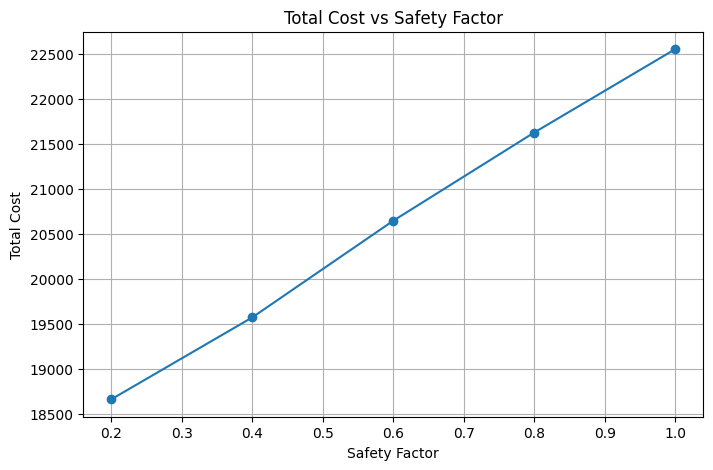

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df['safety_factor'],
    sensitivity_df['total_cost'],
    marker='o'
)
plt.xlabel('Safety Factor')
plt.ylabel('Total Cost')
plt.title('Total Cost vs Safety Factor')
plt.grid(True)
plt.show()

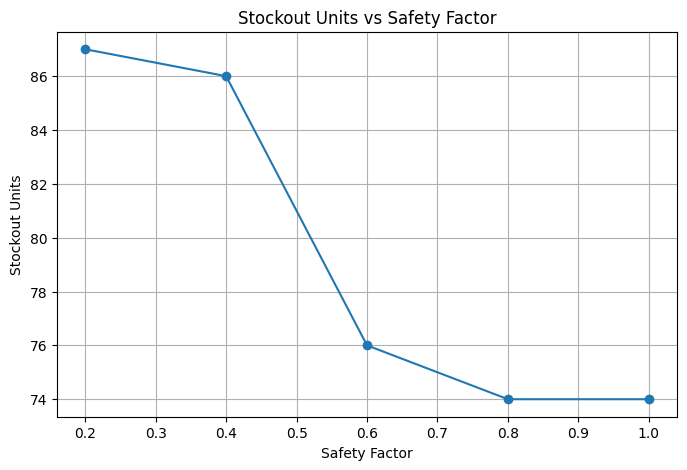

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    sensitivity_df['safety_factor'],
    sensitivity_df['stockout_units'],
    marker='o'
)
plt.xlabel('Safety Factor')
plt.ylabel('Stockout Units')
plt.title('Stockout Units vs Safety Factor')
plt.grid(True)
plt.show()

### Final Safety Factor Selection

Based on the sensitivity analysis, a safety factor of 0.6 was selected as the final tuned conformal inventory policy.

The results show that increasing the safety factor from 0.4 to 0.6 reduced stockout units from 86 to 76, giving a meaningful reduction of 10 stockout units. This improvement came at an additional cost of 1075, resulting in the lowest effective cost per stockout unit reduced among the tested policy options.

Beyond a safety factor of 0.6, the benefits started diminishing. Increasing the factor from 0.6 to 0.8 reduced stockouts by only 2 units while increasing cost by 981. Increasing it further from 0.8 to 1.0 did not reduce stockouts at all, but still increased total cost.

Therefore, 0.6 represents the most practical operating point. It balances inventory cost and service-level protection without unnecessary overstocking.


In [20]:
selected_factor = 0.6

sensitivity_df['selected_policy'] = sensitivity_df['safety_factor'].apply(
    lambda x: 'Selected' if x == selected_factor else ''
)

sensitivity_df

,safety_factor,total_cost,stockout_units,cost_increase,stockout_reduction,cost_per_stockout_reduced,selected_policy
0,0.2,18661.0,87.0,NaN,NaN,NaN,
1,0.4,19572.0,86.0,911.0,1.0,911.0,
2,0.6,20647.0,76.0,1075.0,10.0,107.5,Selected
3,0.8,21628.0,74.0,981.0,2.0,490.5,
4,1.0,22555.0,74.0,927.0,-0.0,NaN,


In [21]:
def label_policy(factor):
    if factor == 0.2:
        return "Low-Cost Conformal Policy"
    elif factor == 0.6:
        return "Tuned Conformal Policy"
    elif factor == 1.0:
        return "Conservative Conformal Policy"
    else:
        return "Intermediate Policy"

sensitivity_df['policy_type'] = sensitivity_df['safety_factor'].apply(label_policy)

sensitivity_df

,safety_factor,total_cost,stockout_units,cost_increase,stockout_reduction,cost_per_stockout_reduced,selected_policy,policy_type
0,0.2,18661.0,87.0,NaN,NaN,NaN,,Low-Cost Conformal Policy
1,0.4,19572.0,86.0,911.0,1.0,911.0,,Intermediate Policy
2,0.6,20647.0,76.0,1075.0,10.0,107.5,Selected,Tuned Conformal Policy
3,0.8,21628.0,74.0,981.0,2.0,490.5,,Intermediate Policy
4,1.0,22555.0,74.0,927.0,-0.0,NaN,,Conservative Conformal Policy


In [22]:
final_policy_comparison = sensitivity_df[
    sensitivity_df['safety_factor'].isin([0.2, 0.6, 1.0])
][[
    'policy_type',
    'safety_factor',
    'total_cost',
    'stockout_units'
]].copy()

final_policy_comparison

,policy_type,safety_factor,total_cost,stockout_units
0,Low-Cost Conformal Policy,0.2,18661.0,87.0
2,Tuned Conformal Policy,0.6,20647.0,76.0
4,Conservative Conformal Policy,1.0,22555.0,74.0


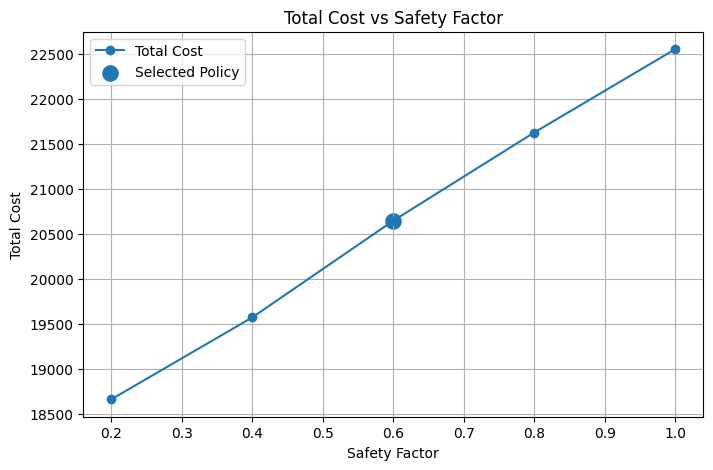

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_df['safety_factor'],
    sensitivity_df['total_cost'],
    marker='o',
    label='Total Cost'
)

selected_row = sensitivity_df[sensitivity_df['safety_factor'] == selected_factor]

plt.scatter(
    selected_row['safety_factor'],
    selected_row['total_cost'],
    s=120,
    label='Selected Policy'
)

plt.xlabel('Safety Factor')
plt.ylabel('Total Cost')
plt.title('Total Cost vs Safety Factor')
plt.legend()
plt.grid(True)
plt.show()

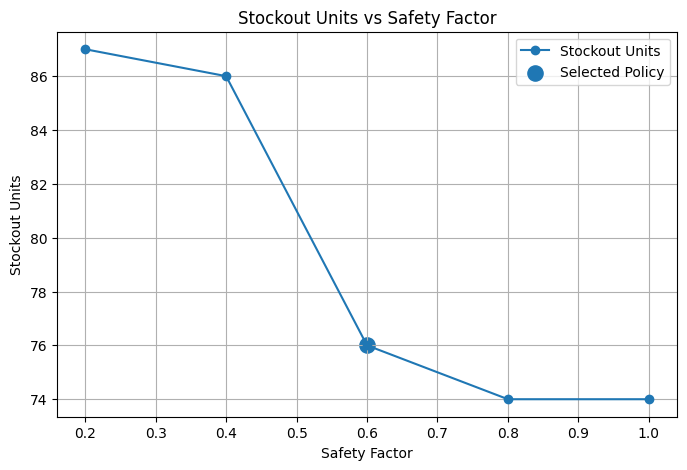

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    sensitivity_df['safety_factor'],
    sensitivity_df['stockout_units'],
    marker='o',
    label='Stockout Units'
)

plt.scatter(
    selected_row['safety_factor'],
    selected_row['stockout_units'],
    s=120,
    label='Selected Policy'
)

plt.xlabel('Safety Factor')
plt.ylabel('Stockout Units')
plt.title('Stockout Units vs Safety Factor')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
sensitivity_df.to_csv("safety_factor_sensitivity_analysis.csv", index=False)
final_policy_comparison.to_csv("final_policy_comparison.csv", index=False)

print("Saved sensitivity analysis and final policy comparison tables.")

Saved sensitivity analysis and final policy comparison tables.


### Final Conclusion

This notebook converted machine learning uncertainty into an inventory decision policy. A LightGBM demand forecasting model was first used to generate point forecasts. Conformal prediction was then applied to estimate uncertainty around these forecasts. Instead of treating this uncertainty as a fixed inventory rule, the conformal interval was used as a flexible safety stock signal.

A sensitivity analysis was performed across different safety factors. The results showed that a safety factor of 0.6 provided the best practical tradeoff between inventory cost and stockout reduction. At this point, total cost was 20,647 and stockout units were reduced to 76. Increasing the safety factor beyond 0.6 increased inventory cost significantly but produced only marginal or no further reduction in stockouts.

Therefore, the tuned conformal policy with a safety factor of 0.6 was selected as the final inventory policy. The key insight is that conformal prediction does not directly force a high-inventory strategy. Instead, it provides an uncertainty-aware decision layer that can be tuned based on business priorities. A cost-sensitive firm may use a lower safety factor, while a service-sensitive firm may use a higher one. The selected tuned policy balances both objectives.


06_inventory_optimization.ipynb

1. Load forecast and conformal interval results
2. Define inventory cost assumptions
3. Compute safety stock from conformal uncertainty
4. Test different safety factors
5. Build sensitivity_df
6. Analyze marginal cost vs stockout reduction
7. Select safety factor = 0.6
8. Compare low-cost, tuned, and conservative conformal policies
9. Visualize total cost and stockouts
10. Final conclusion

In [27]:
import os

print(os.listdir())

['.git', 'data', 'notebooks', 'src', 'reports', 'outputs', '.gitignore', 'README.md', 'requirements.txt', 'safety_factor_sensitivity_analysis.csv', 'final_policy_comparison.csv']


In [35]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/03_baseline_modeling.ipynb
	modified:   notebooks/04_forecast_diagnostics.ipynb
	modified:   notebooks/06_inventory_optimization.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [36]:
!git add notebooks/06_inventory_optimization.ipynb
!git commit -m "Complete inventory optimization and sensitivity analysis"
!git push

[main 0aecd74] Complete inventory optimization and sensitivity analysis
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 525 bytes | 105.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/smrititubid-afk/inventory-optimization-ml-or.git
   1ec2d4b..0aecd74  main -> main


In [37]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/03_baseline_modeling.ipynb
	modified:   notebooks/04_forecast_diagnostics.ipynb
	modified:   notebooks/06_inventory_optimization.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
